In [1]:
from google.colab import files

uploaded = files.upload()

Saving lineups_clean.csv to lineups_clean.csv
Saving matches_clean.csv to matches_clean.csv
Saving player_stats_clean.csv to player_stats_clean.csv
Saving squads_and_players_clean.csv to squads_and_players_clean.csv
Saving team_match_stats_clean.csv to team_match_stats_clean.csv
Saving teams_clean.csv to teams_clean.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
teams = pd.read_csv("teams_clean.csv")
matches = pd.read_csv("matches_clean.csv")
players = pd.read_csv("player_stats_clean.csv")
squads = pd.read_csv("squads_and_players_clean.csv")
lineups = pd.read_csv("lineups_clean.csv")
team_stats = pd.read_csv("team_match_stats_clean.csv")
print(teams.shape)
print(matches.shape)
print(players.shape)
print(squads.shape)
print(lineups.shape)
print(team_stats.shape)

(48, 8)
(104, 17)
(1248, 18)
(1248, 10)
(5408, 7)
(208, 12)


In [5]:
# ======================
# Teams EDA
# ======================

print("Shape:", teams.shape)

teams.head()

Shape: (48, 8)


,team_id,team_name,fifa_code,group_letter,confederation,fifa_ranking_pre_tournament,elo_rating,manager_name
0,1,Mexico,MEX,A,CONCACAF,14,1810,Javier Aguirre
1,2,South Africa,RSA,A,CAF,60,1620,Hugo Broos
2,3,South Korea,KOR,A,AFC,22,1800,Hong Myung-bo
3,4,Czechia,CZE,A,UEFA,40,1740,Miroslav Koubek
4,5,Canada,CAN,B,CONCACAF,33,1795,Jesse Marsch


In [6]:
teams.describe()

,team_id,fifa_ranking_pre_tournament,elo_rating
count,48.00,48.000000,48.000000
mean,24.50,32.687500,1801.562500
std,14.00,23.503876,160.862556
min,1.00,1.000000,1510.000000
25%,12.75,13.750000,1677.500000
50%,24.50,26.500000,1792.500000
75%,36.25,51.000000,1925.000000
max,48.00,85.000000,2150.000000


In [7]:
teams['confederation'].value_counts()

,count
confederation,
UEFA,16
CAF,10
AFC,9
CONCACAF,6
CONMEBOL,6
OFC,1


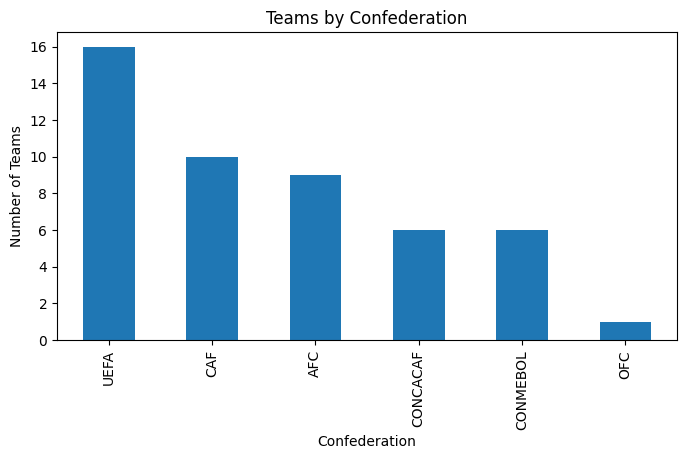

In [8]:
plt.figure(figsize=(8,4))
teams['confederation'].value_counts().plot(kind='bar')
plt.title("Teams by Confederation")
plt.xlabel("Confederation")
plt.ylabel("Number of Teams")
plt.show()

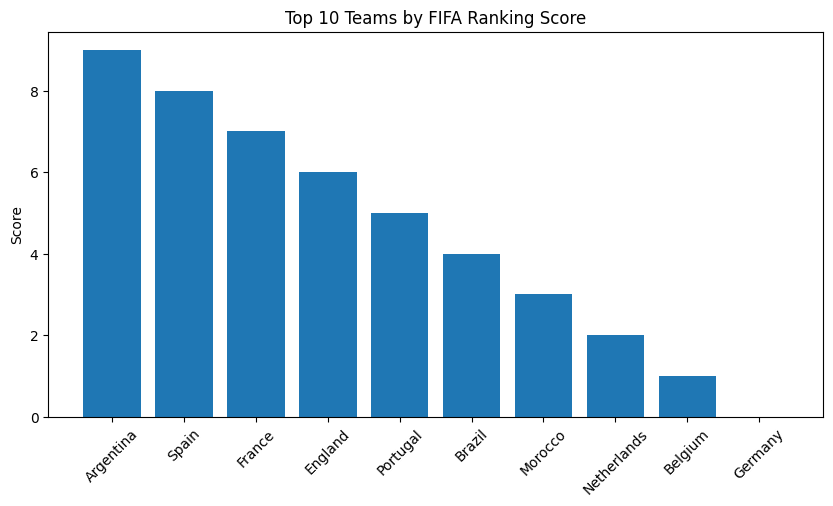

In [9]:
teams['ranking_score'] = 10 - teams['fifa_ranking_pre_tournament']
top_teams = teams.sort_values(
    'ranking_score',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_teams['team_name'],
    top_teams['ranking_score']
)

plt.xticks(rotation=45)
plt.title("Top 10 Teams by FIFA Ranking Score")
plt.ylabel("Score")

plt.show()

In [10]:
# ======================
# Matches EDA
# ======================

print(matches.shape)

matches.head()

(104, 17)


,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,away_penalty_score,status,result_type,home_xg,away_xg,referee_id,player_of_the_match_id
0,1,2026-06-11,19:00,1,1,1,2,2,0,0,0,Completed,Regular,1.84,0.52,1,16
1,2,2026-06-11,23:00,1,7,3,4,2,1,0,0,Completed,Regular,1.45,1.12,2,58
2,3,2026-06-12,19:00,1,6,5,6,1,1,0,0,Completed,Regular,1.35,0.98,3,112
3,4,2026-06-12,23:00,1,3,13,14,4,1,0,0,Completed,Regular,2.76,0.88,4,332
4,5,2026-06-13,15:00,1,10,7,8,1,1,0,0,Completed,Regular,0.78,1.54,5,157


In [11]:
matches.describe()

,match_id,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,away_penalty_score,home_xg,away_xg,referee_id,player_of_the_match_id
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,52.500000,1.605769,8.605769,24.288462,25.826923,1.721154,1.240385,0.105769,0.134615,1.545769,1.108077,9.884615,633.701923
std,30.166206,1.161003,4.829960,13.981036,13.758981,1.503761,1.234576,0.555961,0.683476,0.924910,0.720078,6.499153,358.211086
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.130000,0.080000,1.000000,7.000000
25%,26.750000,1.000000,4.000000,12.750000,14.000000,1.000000,0.000000,0.000000,0.000000,0.780000,0.547500,5.000000,331.250000
50%,52.500000,1.000000,9.000000,25.000000,26.000000,1.000000,1.000000,0.000000,0.000000,1.450000,0.960000,9.000000,668.500000
75%,78.250000,2.000000,13.000000,36.250000,37.250000,3.000000,2.000000,0.000000,0.000000,2.090000,1.480000,14.000000,946.000000
max,104.000000,7.000000,16.000000,48.000000,48.000000,7.000000,6.000000,4.000000,4.000000,4.820000,3.580000,28.000000,1207.000000


In [13]:
matches['total_goals'] = (
    matches['home_score'] +
    matches['away_score']
)

In [14]:
matches['total_goals'].describe()

,total_goals
count,104.000000
mean,2.961538
std,1.863930
min,0.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,10.000000


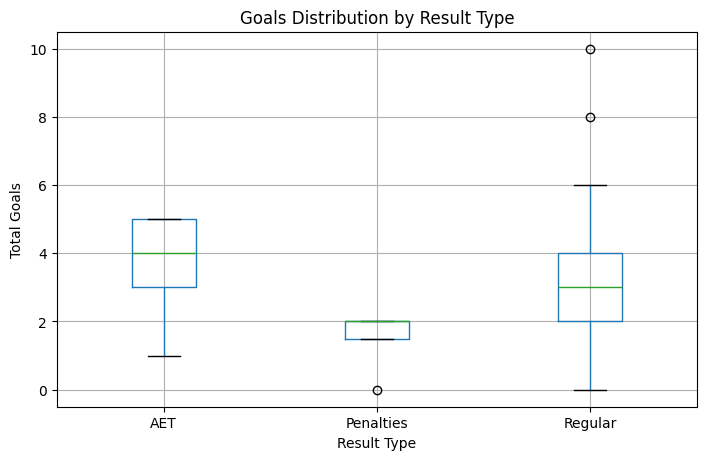

In [15]:
matches.boxplot(column='total_goals', by='result_type', figsize=(8,5))
plt.title("Goals Distribution by Result Type")
plt.suptitle("")
plt.xlabel("Result Type")
plt.ylabel("Total Goals")
plt.show()

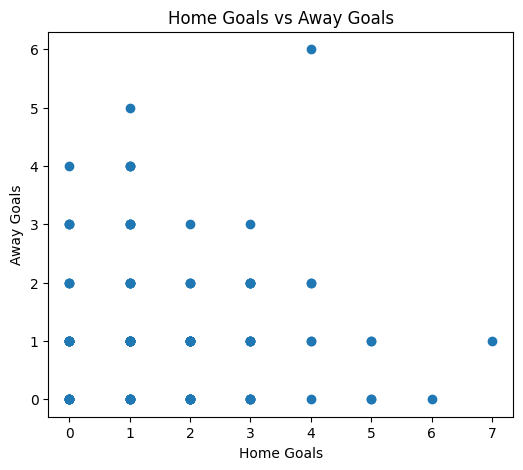

In [16]:
plt.figure(figsize=(6,5))
plt.scatter(matches['home_score'], matches['away_score'])

plt.title("Home Goals vs Away Goals")
plt.xlabel("Home Goals")
plt.ylabel("Away Goals")

plt.show()

In [17]:
# ======================
# Players EDA
# ======================

print(players.shape)

players.head()

(1248, 18)


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,data_source,last_verified
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,0,0,0,0,4.0,7.0,3.0,sofascore.com,2026-07-19
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,1,0,0,0,NaN,NaN,NaN,sofascore.com,2026-07-19
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,0,1,0,0,NaN,NaN,NaN,sofascore.com,2026-07-19
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,1,0,0,0,NaN,NaN,NaN,sofascore.com,2026-07-19
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,1,0,0,0,NaN,NaN,NaN,sofascore.com,2026-07-19


In [18]:
players.describe()

,player_id,team_id,matches_played,matches_started,minutes_played,goals,assists,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded
count,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,1248.000000,145.000000,145.000000,145.000000
mean,624.500000,24.500000,2.616987,1.833333,169.757212,0.237981,0.162660,0.202724,0.012019,0.012821,0.008814,0.379310,4.786207,2.165517
std,360.410877,13.858953,1.908265,1.876571,162.725793,0.769465,0.537287,0.459865,0.109015,0.119458,0.101722,0.972318,7.023953,2.990758
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,312.750000,12.750000,1.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,624.500000,24.500000,3.000000,1.000000,136.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,936.250000,36.250000,4.000000,3.000000,270.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,4.000000
max,1248.000000,48.000000,8.000000,8.000000,810.000000,10.000000,8.000000,3.000000,1.000000,2.000000,2.000000,7.000000,29.000000,10.000000


In [19]:
top_scorers = players.sort_values(
    'goals',
    ascending=False
).head(10)

top_scorers[['player_name','goals']]

,player_name,goals
841,Kylian Mbappe,10
945,Lionel Andrés Messi,8
918,Erling Braut Haaland,7
1153,Jude Victor William Bellingham,7
838,Masour Ousmane Dembele,6
1152,Harry Edward Kane,6
748,Mikel Oyarzabal,5
875,Ismaila Sarr,4
15,Julián Andrés Quinones,4
214,José Vinicius,4


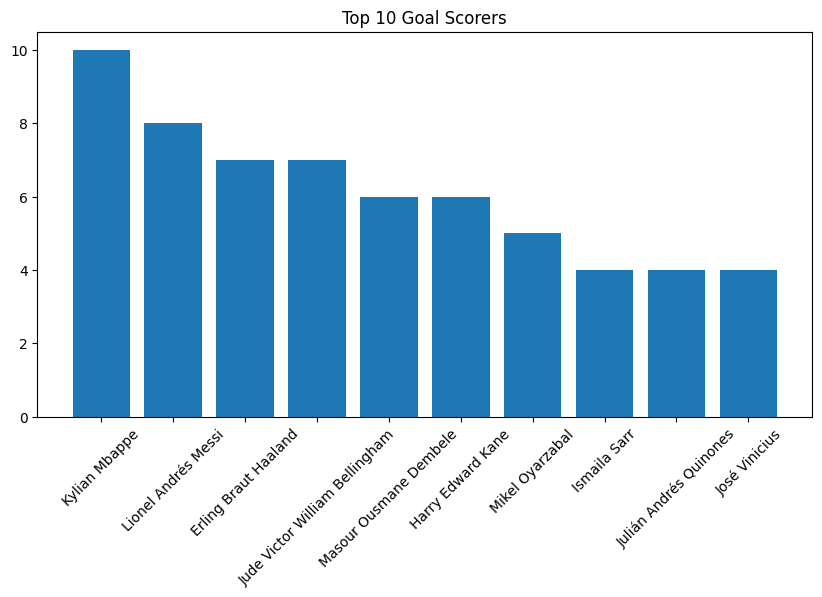

In [20]:
plt.figure(figsize=(10,5))
plt.bar(
    top_scorers['player_name'],
    top_scorers['goals']
)

plt.xticks(rotation=45)
plt.title("Top 10 Goal Scorers")
plt.show()

In [21]:
Top_Assists = players.sort_values(
    'assists',
    ascending=False
).head(5)
Top_Assists[['player_name','assists']]

,player_name,assists
842,Michael Akpovie Olise,8
841,Kylian Mbappe,4
215,GUIMARAESBruno Bruno,4
243,Brahim Diaz,4
945,Lionel Andrés Messi,4


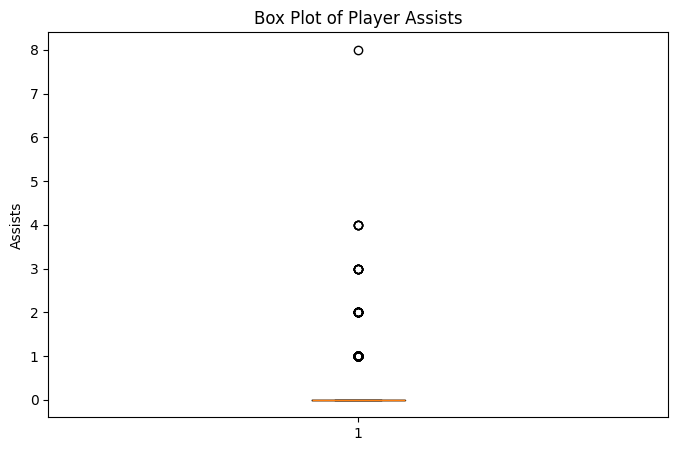

In [22]:
plt.figure(figsize=(8,5))

plt.boxplot(players['assists'])

plt.title("Box Plot of Player Assists")
plt.ylabel("Assists")

plt.show()

In [23]:
players['total_contributions'] = (
    players['goals'] +
    players['assists']
)

In [25]:
top_contributors = players.nlargest(10, 'total_contributions')

top_contributors[['player_name', 'goals', 'assists', 'total_contributions']]

,player_name,goals,assists,total_contributions
841,Kylian Mbappe,10,4,14
945,Lionel Andrés Messi,8,4,12
842,Michael Akpovie Olise,0,8,8
1153,Jude Victor William Bellingham,7,1,8
838,Masour Ousmane Dembele,6,1,7
918,Erling Braut Haaland,7,0,7
1152,Harry Edward Kane,6,1,7
748,Mikel Oyarzabal,5,1,6
1150,Bukayo Ayoyinka Saka,3,3,6
15,Julián Andrés Quinones,4,1,5


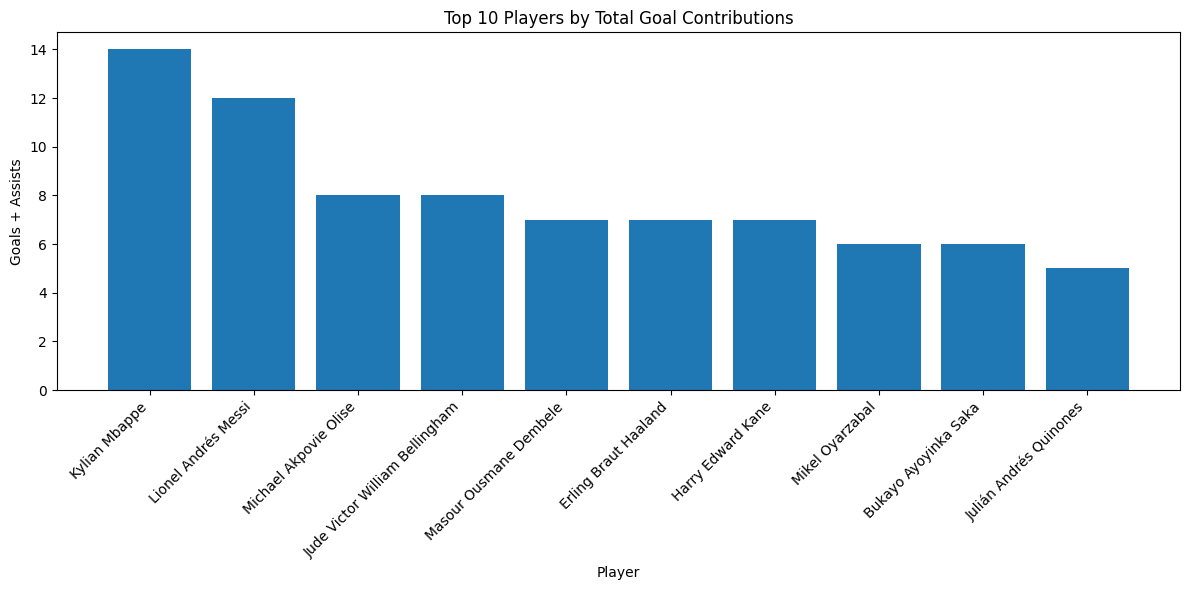

In [26]:
plt.figure(figsize=(12,6))

plt.bar(
    top_contributors['player_name'],
    top_contributors['total_contributions']
)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Players by Total Goal Contributions")
plt.xlabel("Player")
plt.ylabel("Goals + Assists")

plt.tight_layout()
plt.show()

In [27]:
players['total_cards'] = players['yellow_cards'] + players['red_cards']
cards_by_position = players.groupby('position')['total_cards'].sum()


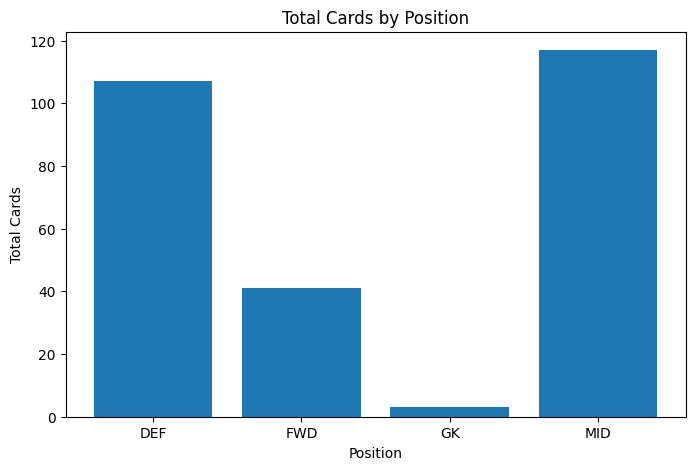

In [28]:
plt.figure(figsize=(8,5))

plt.bar(
    cards_by_position.index,
    cards_by_position.values
)

plt.title("Total Cards by Position")
plt.xlabel("Position")
plt.ylabel("Total Cards")

plt.show()

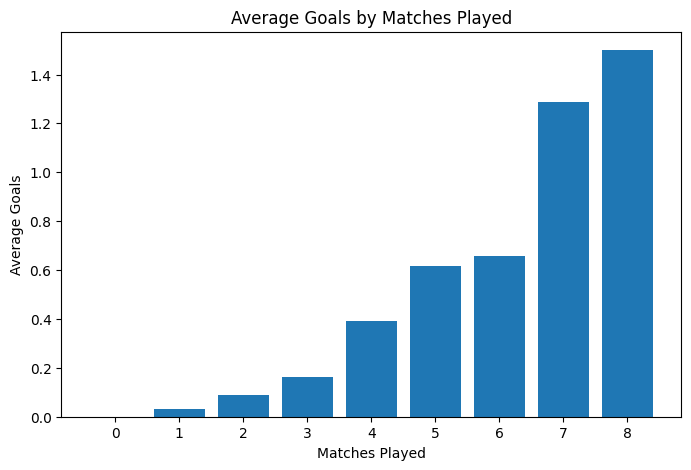

In [29]:
goals_by_matches = players.groupby('matches_played')['goals'].mean()

plt.figure(figsize=(8,5))

plt.bar(
    goals_by_matches.index.astype(str),
    goals_by_matches.values
)

plt.title("Average Goals by Matches Played")
plt.xlabel("Matches Played")
plt.ylabel("Average Goals")

plt.show()

In [30]:
#======================
# squads_and_players EDA
# ======================

print(squads.shape)

squads.head()

(1248, 10)


,player_id,team_id,player_name,position,club_team,market_value_eur,caps,date_of_birth,height_cm,goals
0,1,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3


In [31]:
top_clubs = squads['club_team'].value_counts().head(10)

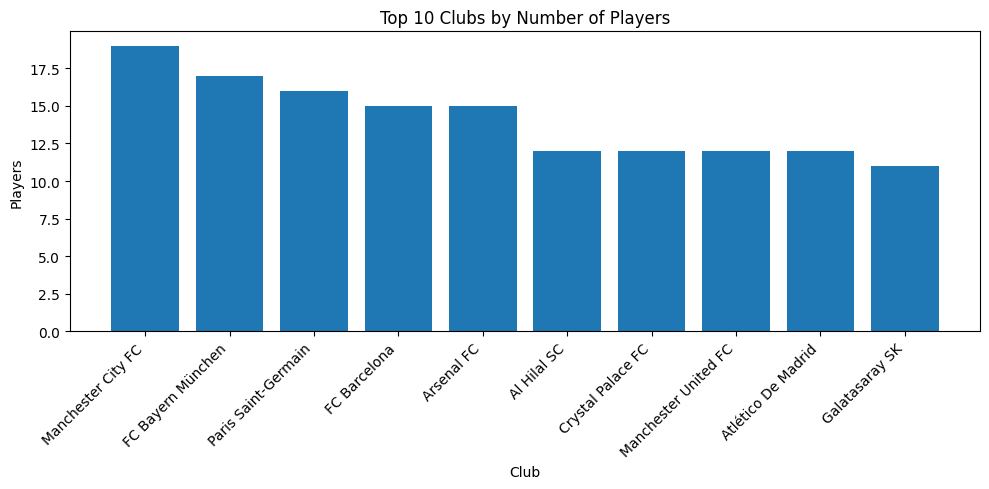

In [32]:
plt.figure(figsize=(10,5))

plt.bar(
    top_clubs.index,
    top_clubs.values
)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Clubs by Number of Players")
plt.xlabel("Club")
plt.ylabel("Players")

plt.tight_layout()
plt.show()

In [33]:
top_value = squads.nlargest(10, 'market_value_eur')

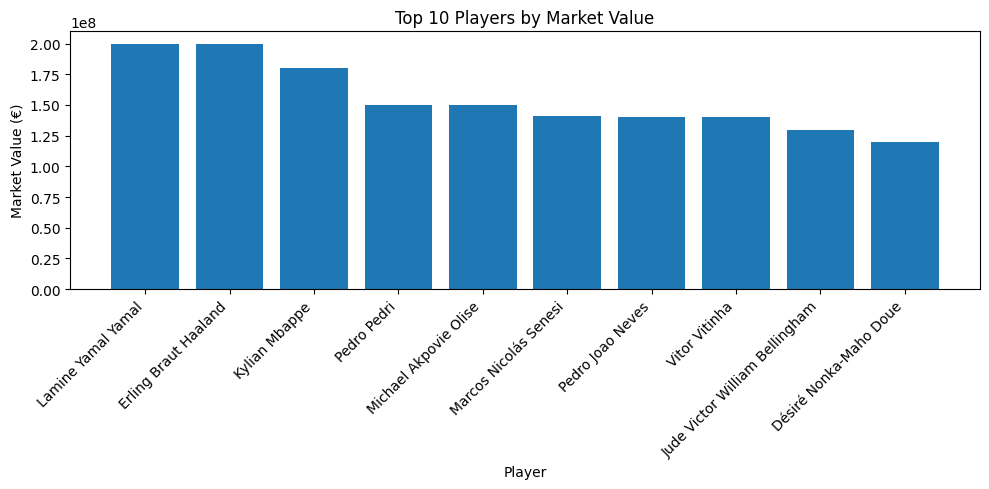

In [34]:
plt.figure(figsize=(10,5))

plt.bar(
    top_value['player_name'],
    top_value['market_value_eur']
)

plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Players by Market Value")
plt.xlabel("Player")
plt.ylabel("Market Value (€)")

plt.tight_layout()
plt.show()

In [35]:
caps_count = squads['caps'].value_counts().sort_index().head(20)

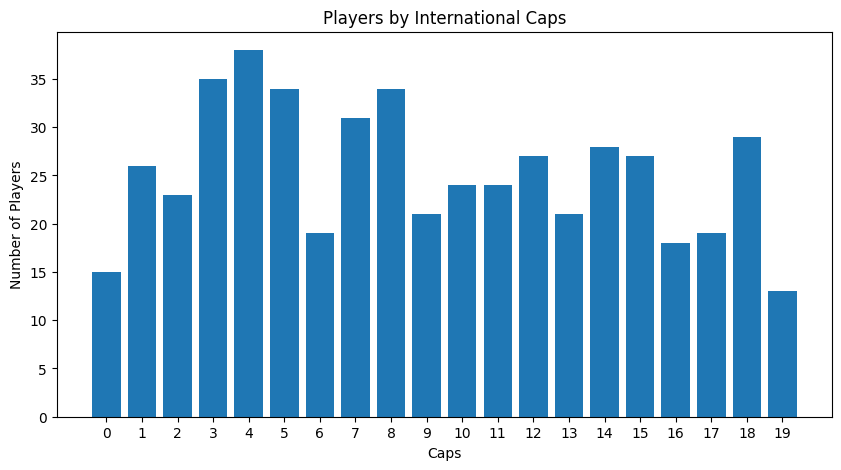

In [36]:
plt.figure(figsize=(10,5))

plt.bar(caps_count.index.astype(str), caps_count.values)

plt.title("Players by International Caps")
plt.xlabel("Caps")
plt.ylabel("Number of Players")

plt.show()

In [38]:
top_goals = squads.nlargest(10, 'goals')

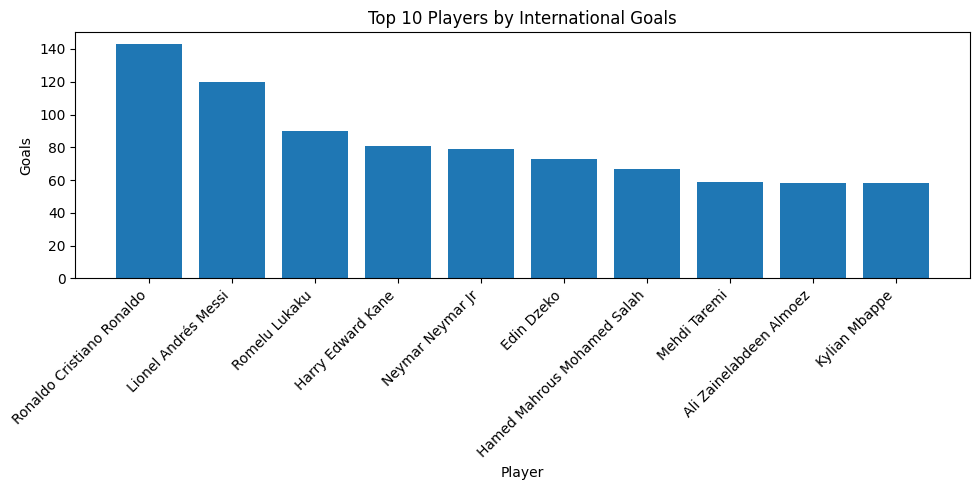

In [39]:
plt.figure(figsize=(10,5))

plt.bar(top_goals['player_name'], top_goals['goals'])

plt.xticks(rotation=45, ha='right')

plt.title("Top 10 Players by International Goals")
plt.xlabel("Player")
plt.ylabel("Goals")

plt.tight_layout()
plt.show()

In [40]:
# ======================
# Team_stats EDA
# ======================

print("Shape:", team_stats.shape)
team_stats.head()

Shape: (208, 12)


,match_id,team_id,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves,player_of_the_match,data_source,last_updated
0,1,1,57,16,4,6,11,2,1,Julián Andrés Quinones,fifa.com,2026-06-24
1,1,2,43,3,2,3,15,1,4,Unknown,fifa.com,2026-06-24
2,2,3,54,12,5,4,10,1,2,Inbeom Hwang,sofascore.com,2026-06-24
3,2,4,46,10,3,3,13,2,4,Unknown,sofascore.com,2026-06-24
4,3,5,52,13,4,9,12,2,3,Ismaël Kenneth Jordan Kone,fifa.com,2026-06-24


In [41]:
team_stats.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             208 non-null    int64 
 1   team_id              208 non-null    int64 
 2   possession_pct       208 non-null    int64 
 3   total_shots          208 non-null    int64 
 4   shots_on_target      208 non-null    int64 
 5   corners              208 non-null    int64 
 6   fouls                208 non-null    int64 
 7   offsides             208 non-null    int64 
 8   saves                208 non-null    int64 
 9   player_of_the_match  208 non-null    object
 10  data_source          208 non-null    object
 11  last_updated         208 non-null    object
dtypes: int64(9), object(3)
memory usage: 19.6+ KB


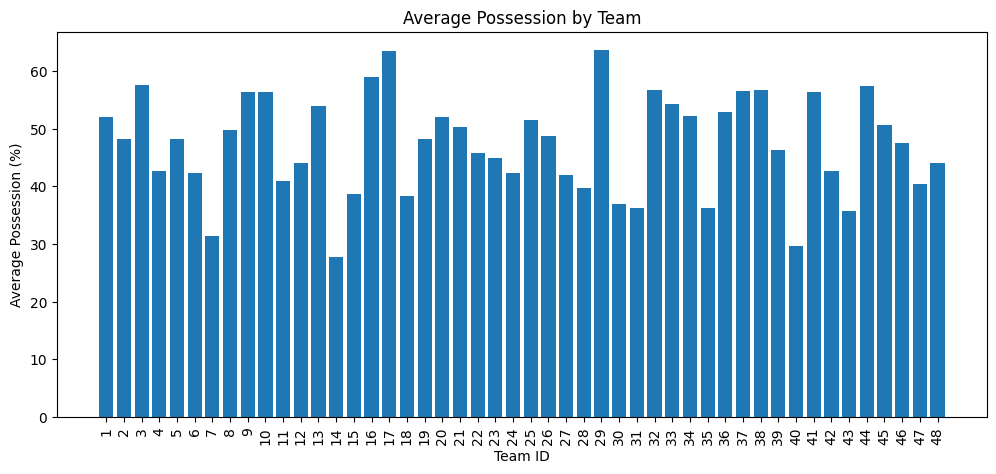

In [42]:
avg_possession = team_stats.groupby('team_id')['possession_pct'].mean()


plt.figure(figsize=(12,5))

plt.bar(
    avg_possession.index.astype(str),
    avg_possession.values
)

plt.title("Average Possession by Team")
plt.xlabel("Team ID")
plt.ylabel("Average Possession (%)")

plt.xticks(rotation=90)

plt.show()

In [44]:
top_shots = team_stats.groupby('team_id')['total_shots'].sum().nlargest(10)

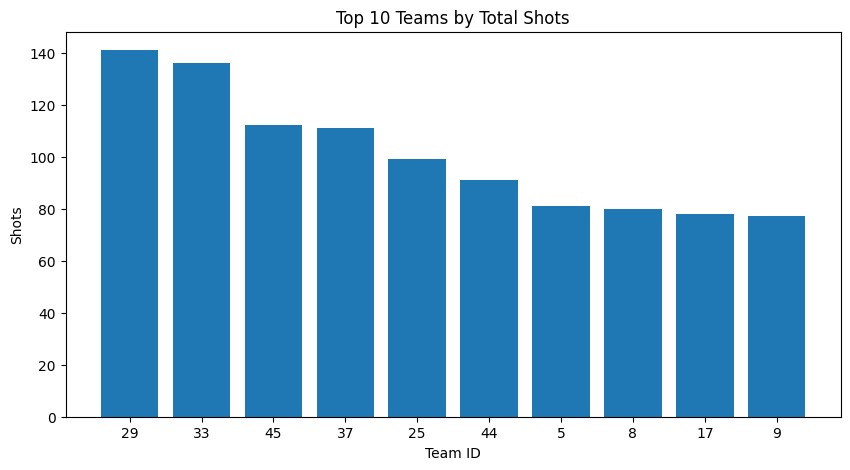

In [45]:
plt.figure(figsize=(10,5))

plt.bar(
    top_shots.index.astype(str),
    top_shots.values
)

plt.title("Top 10 Teams by Total Shots")
plt.xlabel("Team ID")
plt.ylabel("Shots")

plt.show()

In [46]:
top_fouls = team_stats.groupby('team_id')['fouls'].sum().nlargest(10)

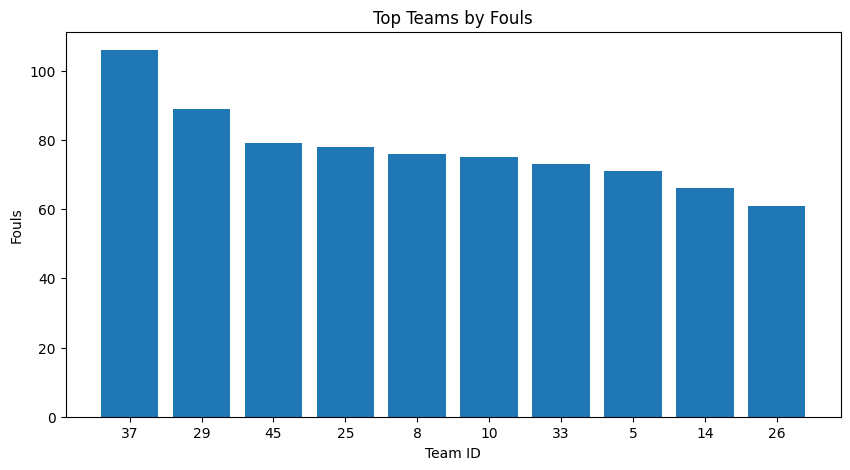

In [47]:
plt.figure(figsize=(10,5))

plt.bar(
    top_fouls.index.astype(str),
    top_fouls.values
)

plt.title("Top Teams by Fouls")
plt.xlabel("Team ID")
plt.ylabel("Fouls")

plt.show()

In [48]:
top_target = team_stats.groupby('team_id')['shots_on_target'].sum().nlargest()

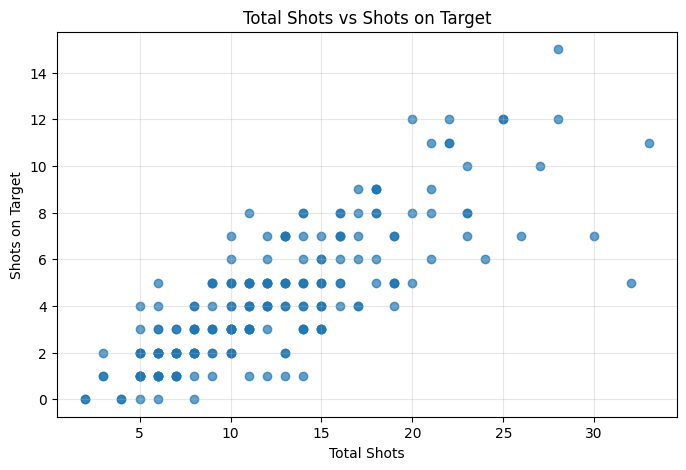

In [49]:
plt.figure(figsize=(8,5))

plt.scatter(
    team_stats['total_shots'],
    team_stats['shots_on_target'],
    alpha=0.7
)

plt.title("Total Shots vs Shots on Target")
plt.xlabel("Total Shots")
plt.ylabel("Shots on Target")

plt.grid(alpha=0.3)

plt.show()

In [50]:
# ======================
# lineups EDA
# ======================
lineups.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5408 entries, 0 to 5407
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   lineup_id          5408 non-null   int64 
 1   match_id           5408 non-null   int64 
 2   player_id          5408 non-null   int64 
 3   team_id            5408 non-null   int64 
 4   is_starting_xi     5408 non-null   int64 
 5   tactical_position  5408 non-null   object
 6   minutes_played     5408 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 295.9+ KB


In [51]:
lineups.head()

,lineup_id,match_id,player_id,team_id,is_starting_xi,tactical_position,minutes_played
0,1,1,1,1,1,GK,90
1,2,1,2,1,0,DEF,0
2,3,1,3,1,1,DEF,90
3,4,1,4,1,0,DEF,14
4,5,1,5,1,1,DEF,90


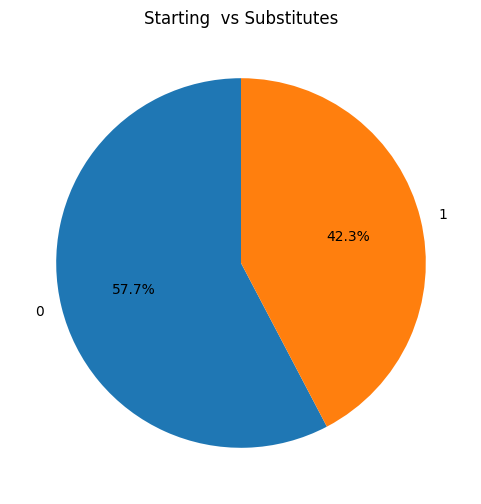

In [52]:
starting = lineups['is_starting_xi'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    starting.values,
    labels=starting.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Starting  vs Substitutes")

plt.show()

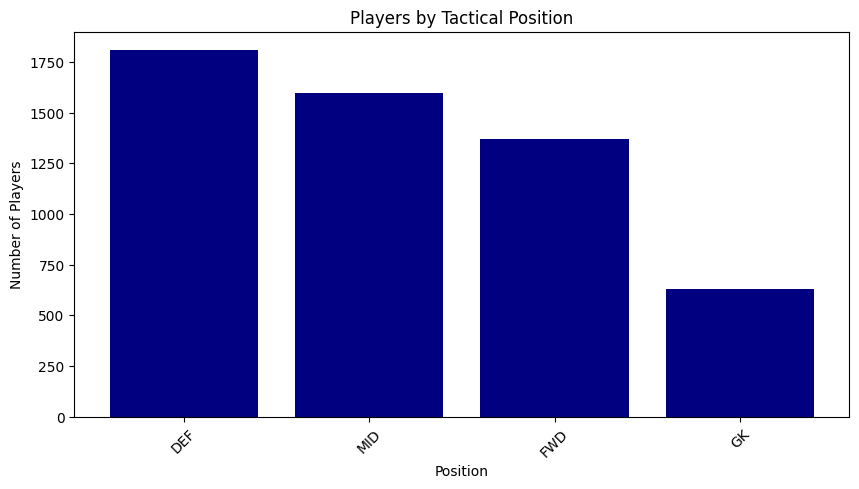

In [53]:
positions = lineups['tactical_position'].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    positions.index,
    positions.values,
    color='navy'

)

plt.xticks(rotation=45)
plt.title("Players by Tactical Position")
plt.xlabel("Position")
plt.ylabel("Number of Players")

plt.show()

In [54]:
player_full = players.merge(
    squads,
    on='player_id',
    how='left'
)

In [55]:
player_full.head()

,player_id,player_name_x,team_id_x,position_x,matches_played,matches_started,minutes_played,goals_x,assists,yellow_cards,...,total_cards,team_id_y,player_name_y,position_y,club_team,market_value_eur,caps,date_of_birth,height_cm,goals_y
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,0,...,0,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,1,...,1,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,0,...,1,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,1,...,1,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,1,...,1,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3


In [56]:
match_full = matches.merge(
    team_stats,
    on='match_id',
    how='left'
)

In [57]:
match_full.head()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,...,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves,player_of_the_match,data_source,last_updated
0,1,2026-06-11,19:00,1,1,1,2,2,0,0,...,57,16,4,6,11,2,1,Julián Andrés Quinones,fifa.com,2026-06-24
1,1,2026-06-11,19:00,1,1,1,2,2,0,0,...,43,3,2,3,15,1,4,Unknown,fifa.com,2026-06-24
2,2,2026-06-11,23:00,1,7,3,4,2,1,0,...,54,12,5,4,10,1,2,Inbeom Hwang,sofascore.com,2026-06-24
3,2,2026-06-11,23:00,1,7,3,4,2,1,0,...,46,10,3,3,13,2,4,Unknown,sofascore.com,2026-06-24
4,3,2026-06-12,19:00,1,6,5,6,1,1,0,...,52,13,4,9,12,2,3,Ismaël Kenneth Jordan Kone,fifa.com,2026-06-24


In [58]:
match_full = match_full.merge(
    teams[['team_id', 'team_name']],
    on='team_id',
    how='left'
)

In [59]:
lineup_full = lineups.merge(
    player_full,
    on='player_id',
    how='left'
)

In [60]:
lineup_full.head()

,lineup_id,match_id,player_id,team_id,is_starting_xi,tactical_position,minutes_played_x,player_name_x,team_id_x,position_x,...,total_cards,team_id_y,player_name_y,position_y,club_team,market_value_eur,caps,date_of_birth,height_cm,goals_y
0,1,1,1,1,1,GK,90,José Raúl Rangel,1,GK,...,0,1,José Raúl Rangel,GK,CD Guadalajara,8933646,15,2000-02-25,190,0
1,2,1,2,1,0,DEF,0,Jorge Eduardo Sanchez,1,DEF,...,1,1,Jorge Eduardo Sanchez,DEF,PAOK Saloniki,24628639,59,1997-12-10,176,3
2,3,1,3,1,1,DEF,90,César Jasib Montes,1,DEF,...,1,1,César Jasib Montes,DEF,FC Lokomotiv Moscow,10912552,69,1997-02-24,191,4
3,4,1,4,1,0,DEF,14,Edson Omar Alvarez,1,DEF,...,1,1,Edson Omar Alvarez,DEF,Fenerbahçe SK,10875943,100,1997-10-24,180,7
4,5,1,5,1,1,DEF,90,Johan Felipe Vasquez,1,DEF,...,1,1,Johan Felipe Vasquez,DEF,Genoa CFC,18265363,47,1998-10-22,182,3




>Feature Engineering : player









In [76]:
# 1. Total Contributions
player_full['total_contributions'] = (
    players['goals'] +
    players['assists']
)


In [78]:
# 2. Goals per Match
player_full['goals_per_match'] = np.where(
    players['matches_played'] > 0,
    players['goals'] / player_full['matches_played'],
    0
)


In [80]:
# 3. Assists per Match
player_full['assists_per_match'] = np.where(
    players['matches_played'] > 0,
    players['assists'] / player_full['matches_played'],
    0
)

In [81]:
# 4. Goal Contributions per Match
player_full['contribution_per_match'] = np.where(
    player_full['matches_played'] > 0,
    player_full['total_contributions'] / player_full['matches_played'],
    0
)

In [82]:
# 5. Total Cards
player_full['total_cards'] = (
    player_full['yellow_cards'] +
    player_full['red_cards']
)

In [83]:
# 6. Discipline Score
player_full['discipline_score'] = (
    player_full['yellow_cards'] +
    (player_full['red_cards'] * 2)
)

In [90]:
# 7. Minutes per Goal
player_full['minutes_per_goal'] = np.where(
    players['goals'] > 0,
    players['minutes_played'] / players['goals'],
    0
)


In [91]:
# 8. Minutes per Contribution
player_full['minutes_per_contribution'] = np.where(
    player_full['total_contributions'] > 0,
    player_full['minutes_played'] / player_full['total_contributions'],
    0
)

In [92]:
# 9. Clean Sheet Rate
player_full['clean_sheet_rate'] = np.where(
    player_full['matches_played'] > 0,
    player_full['clean_sheets'] / player_full['matches_played'],
    0
)


In [93]:
player_full.head()

,player_id,player_name_x,team_id_x,position_x,matches_played,matches_started,minutes_played,goals_x,assists,yellow_cards,...,date_of_birth,height_cm,goals_y,goals_per_match,assists_per_match,contribution_per_match,discipline_score,minutes_per_goal,minutes_per_contribution,clean_sheet_rate
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,0,...,2000-02-25,190,0,0.0,0.00,0.00,0,0.0,0.0,0.8
1,2,Jorge Eduardo Sanchez,1,DEF,4,4,349,0,1,1,...,1997-12-10,176,3,0.0,0.25,0.25,1,0.0,349.0,NaN
2,3,César Jasib Montes,1,DEF,4,4,315,0,0,0,...,1997-02-24,191,4,0.0,0.00,0.00,2,0.0,0.0,NaN
3,4,Edson Omar Alvarez,1,DEF,4,2,239,0,0,1,...,1997-10-24,180,7,0.0,0.00,0.00,1,0.0,0.0,NaN
4,5,Johan Felipe Vasquez,1,DEF,4,4,360,0,0,1,...,1998-10-22,182,3,0.0,0.00,0.00,1,0.0,0.0,NaN




> Feature Engineering :  matches




In [94]:
# 1. Total Goals
matches['total_goals'] = (
    matches['home_score'] +
    matches['away_score']
)

# 2. Goal Difference
matches['goal_difference'] = abs(
    matches['home_score'] -
    matches['away_score']
)

# 3. Match Result
matches['match_result'] = np.where(
    matches['home_score'] > matches['away_score'],
    'Home Win',
    np.where(
        matches['home_score'] < matches['away_score'],
        'Away Win',
        'Draw'
    )
)

# 4.high match scoring
matches['high_scoring_match'] = (
    matches['total_goals'] >= 3
)

# 5. Clean Sheet Match
matches['clean_sheet_match'] = (
    (matches['home_score'] == 0) |
    (matches['away_score'] == 0)
)

# 6. Both Teams Scored (BTTS)
matches['both_teams_scored'] = (
    (matches['home_score'] > 0) &
    (matches['away_score'] > 0)
)

# 7. Home Win
matches['home_win'] = (
    matches['home_score'] >
    matches['away_score']
)

# 8. Away Win
matches['away_win'] = (
    matches['away_score'] >
    matches['home_score']
)

# 9. Draw
matches['draw'] = (
    matches['home_score'] ==
    matches['away_score']
)

In [95]:
matches.head()

,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,...,player_of_the_match_id,total_goals,goal_difference,match_result,high_scoring_match,clean_sheet_match,both_teams_scored,home_win,away_win,draw
0,1,2026-06-11,19:00,1,1,1,2,2,0,0,...,16,2,2,Home Win,False,True,False,True,False,False
1,2,2026-06-11,23:00,1,7,3,4,2,1,0,...,58,3,1,Home Win,True,False,True,True,False,False
2,3,2026-06-12,19:00,1,6,5,6,1,1,0,...,112,2,0,Draw,False,False,True,False,False,True
3,4,2026-06-12,23:00,1,3,13,14,4,1,0,...,332,5,3,Home Win,True,False,True,True,False,False
4,5,2026-06-13,15:00,1,10,7,8,1,1,0,...,157,2,0,Draw,False,False,True,False,False,True




> Feature Engineering : team_stats



In [96]:
# 1. Shot Accuracy
team_stats['shot_accuracy'] = np.where(
    team_stats['total_shots'] > 0,
    team_stats['shots_on_target'] / team_stats['total_shots'],
    0
)

# 2. Shots Off Target
team_stats['shots_off_target'] = (
    team_stats['total_shots'] -
    team_stats['shots_on_target']
)

# 3. Saves per Shot on Target
team_stats['save_rate'] = np.where(
    team_stats['shots_on_target'] > 0,
    team_stats['saves'] / team_stats['shots_on_target'],
    0
)

# 4. Fouls per Shot
team_stats['fouls_per_shot'] = np.where(
    team_stats['total_shots'] > 0,
    team_stats['fouls'] / team_stats['total_shots'],
    0
)

# 5. Corners per Shot
team_stats['corners_per_shot'] = np.where(
    team_stats['total_shots'] > 0,
    team_stats['corners'] / team_stats['total_shots'],
    0
)

# 6. Offsides per Shot
team_stats['offsides_per_shot'] = np.where(
    team_stats['total_shots'] > 0,
    team_stats['offsides'] / team_stats['total_shots'],
    0
)

# 7. Aggressive Play Index
team_stats['aggressive_play_index'] = (
    team_stats['fouls'] +
    team_stats['offsides']
)

In [97]:
team_stats.head()

,match_id,team_id,possession_pct,total_shots,shots_on_target,corners,fouls,offsides,saves,player_of_the_match,data_source,last_updated,shot_accuracy,shots_off_target,save_rate,fouls_per_shot,corners_per_shot,offsides_per_shot,aggressive_play_index
0,1,1,57,16,4,6,11,2,1,Julián Andrés Quinones,fifa.com,2026-06-24,0.250000,12,0.250000,0.687500,0.375000,0.125000,13
1,1,2,43,3,2,3,15,1,4,Unknown,fifa.com,2026-06-24,0.666667,1,2.000000,5.000000,1.000000,0.333333,16
2,2,3,54,12,5,4,10,1,2,Inbeom Hwang,sofascore.com,2026-06-24,0.416667,7,0.400000,0.833333,0.333333,0.083333,11
3,2,4,46,10,3,3,13,2,4,Unknown,sofascore.com,2026-06-24,0.300000,7,1.333333,1.300000,0.300000,0.200000,15
4,3,5,52,13,4,9,12,2,3,Ismaël Kenneth Jordan Kone,fifa.com,2026-06-24,0.307692,9,0.750000,0.923077,0.692308,0.153846,14
